In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import json

In [3]:
all_pred = []
all_true = []
for loss in ["SMAPE", "MSLE", ""]:
    pred = pd.read_csv(f"/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/HCC70/{loss}/valid_output_states.csv", index_col=0)
    true = pd.read_csv(f"/dccstor/ipc1/CAR/DREAM/Model/Test/After_synthetic/HCC70/{loss}/valid_data.csv", index_col=0).reset_index(drop=True)

    pred["loss"] = "MSE" if loss=="" else loss
    true["loss"] = "MSE" if loss=="" else loss
    
    all_pred.append(pred)
    all_true.append(true)

In [5]:
all_pred = pd.concat(all_pred)
all_true = pd.concat(all_true)

In [9]:
markers = set(all_pred.columns).intersection(set(all_true.columns)) - set("loss")
eval_markers = ["RB", "p53", "p38", "JNK", "GSK3B", "cleavedCas", "MKK36", "MAPKAPK2", 
                "FAK", "CREB", "H3", "p90RSK", "ERK12"]
r2_scores = []
correlations = []
for loss in ["SMAPE", "MSLE", "MSE"]:
    for marker in eval_markers:
        corr = all_true.loc[all_true["loss"]==loss, marker].corr(all_pred.loc[all_pred["loss"]==loss, marker], method='pearson')
        correlations.append(corr)
        r2 = r2_score(all_true.loc[all_true["loss"]==loss, marker], all_pred.loc[all_pred["loss"]==loss, marker])
        r2_scores.append(r2)

In [16]:
res = pd.DataFrame({"loss": [l for l in ["SMAPE", "MSLE", "MSE"] for m in eval_markers],
                   "marker": [m for l in loss for m in eval_markers ],
                  "r2": r2_scores,
                  "correlation": correlations})

<AxesSubplot:xlabel='r2', ylabel='marker'>

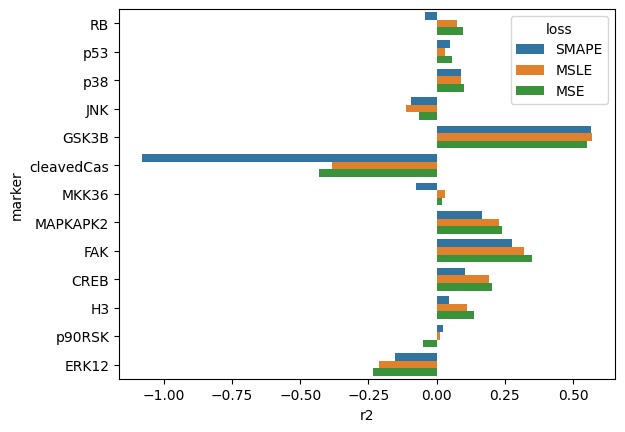

In [18]:
sns.barplot(data=res, y="marker", x="r2", hue="loss")

<AxesSubplot:xlabel='correlation', ylabel='marker'>

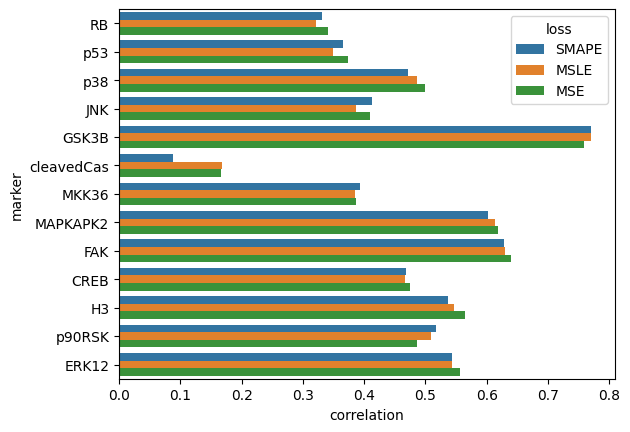

In [20]:
sns.barplot(data=res, y="marker", x="correlation", hue="loss")